In [23]:
#%%
import pandas as pd
import os
import talib as ta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates # For date formatting
from matplotlib.ticker import MaxNLocator # For controlling tick density

# load_and_clean_stock_data function (from previous response)
# ... (make sure this function is defined here) ...
def load_and_clean_stock_data(csv_filepath, ticker_symbol):
    try:
        df = pd.read_csv(csv_filepath, parse_dates=['Date'], index_col='Date')
        column_mapping = {'Open': 'Open', 'High': 'High', 'Low': 'Low', 'Close': 'Close', 'Adj Close': 'Adj Close', 'Volume': 'Volume'}
        cols_to_rename = {k: v for k, v in column_mapping.items() if k in df.columns}
        df.rename(columns=cols_to_rename, inplace=True)
        standard_columns = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
        columns_to_keep = [col for col in standard_columns if col in df.columns]
        df = df[columns_to_keep]
        for col in columns_to_keep:
            if col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce')
        missing_values = df.isnull().sum()
        if missing_values.sum() > 0:
            df.ffill(inplace=True)
            df.bfill(inplace=True)
        df.sort_index(inplace=True)
        return df
    except Exception: return None

def analyze_and_plot_stock(df_stock, ticker_symbol, analysis_date_str=None, plot_lookback_days=None):
    """
    Calculates indicators, shows data for a specific date, and plots for a single stock.

    Args:
        df_stock (pd.DataFrame): The cleaned DataFrame for the stock.
        ticker_symbol (str): The stock's ticker symbol.
        analysis_date_str (str, optional): Specific date 'YYYY-MM-DD' for detailed view.
                                           If None, uses the latest date.
        plot_lookback_days (int, optional): Number of recent days to plot.
                                            If None, plots all available data.
    """
    if df_stock is None or df_stock.empty:
        print(f"No data provided for {ticker_symbol} to analyze and plot.")
        return

    print(f"\n--- {ticker_symbol} Analysis ---")

    # 1. Calculate Technical Indicators (same as before)
    print(f"Calculating TA-Lib indicators for {ticker_symbol}...")
    try:
        close_prices = df_stock['Close'].dropna()
        if len(close_prices) > 1:
            df_stock['SMA_20'] = ta.SMA(close_prices, timeperiod=20)
            df_stock['SMA_50'] = ta.SMA(close_prices, timeperiod=50)
            df_stock['RSI'] = ta.RSI(close_prices, timeperiod=14)
            macd, macdsignal, macdhist = ta.MACD(close_prices, fastperiod=12, slowperiod=26, signalperiod=9)
            df_stock['MACD'] = macd
            df_stock['MACD_Signal'] = macdsignal
            df_stock['MACD_Hist'] = macdhist
            # print(f"Indicators calculated for {ticker_symbol}.") # Less verbose
        else:
            # print(f"Not enough 'Close' data for {ticker_symbol}.") # Less verbose
            for col in ['SMA_20', 'SMA_50', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist']:
                if col not in df_stock.columns: df_stock[col] = pd.NA
    except Exception as e:
        print(f"Error calculating indicators for {ticker_symbol}: {e}")
        for col in ['SMA_20', 'SMA_50', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist']:
            if col not in df_stock.columns: df_stock[col] = pd.NA


    # 2. Specific Date Analysis (same as before)
    if not df_stock.index.empty:
        if analysis_date_str:
            try:
                target_analysis_date = pd.Timestamp(analysis_date_str)
            except ValueError:
                print(f"Invalid date string '{analysis_date_str}'. Using latest date.")
                target_analysis_date = df_stock.index[-1]
        else:
            target_analysis_date = df_stock.index[-1]

        if target_analysis_date in df_stock.index:
            print(f"\n--- {ticker_symbol} Data for {target_analysis_date.strftime('%Y-%m-%d')} ---")
            pd.set_option('display.float_format', '{:.2f}'.format)
            print(df_stock.loc[target_analysis_date])
            pd.reset_option('display.float_format')
        # else:
            # print(f"Target analysis date {target_analysis_date.strftime('%Y-%m-%d')} not found.") # Less verbose
    # else:
        # print(f"No dates available in {ticker_symbol} data.") # Less verbose


    # 3. Plotting with Time Frame Control
    print(f"Generating plot for {ticker_symbol}...")
    
    if plot_lookback_days is not None and isinstance(plot_lookback_days, int) and plot_lookback_days > 0:
        plot_df = df_stock.last(f'{plot_lookback_days}D').copy() # Get last N calendar days
        if plot_df.empty and not df_stock.empty: # Fallback if last N days is empty (e.g. weekend)
             plot_df = df_stock.tail(plot_lookback_days).copy() # Get last N trading days
        plot_title_suffix = f"(Last {plot_lookback_days} Days)"
    else:
        plot_df = df_stock.copy()
        plot_title_suffix = "(Full History)"

    if not plot_df.empty:
        # Increase figure size for better clarity
        fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True, 
                                 gridspec_kw={'height_ratios': [3, 1, 1]}) # Adjusted height ratios
        fig.suptitle(f'{ticker_symbol} Price and Technical Indicators {plot_title_suffix}', fontsize=16)

        # Plot 1: Close Price and SMAs
        axes[0].plot(plot_df.index, plot_df['Close'], label='Close Price', color='blue', linewidth=1.5) # Slightly thicker Close
        if 'SMA_20' in plot_df.columns:
            axes[0].plot(plot_df.index, plot_df['SMA_20'], label='SMA 20-day', color='orange', linestyle='--', linewidth=1)
        if 'SMA_50' in plot_df.columns:
            axes[0].plot(plot_df.index, plot_df['SMA_50'], label='SMA 50-day', color='darkgreen', linestyle=':', linewidth=1) # Different style for SMA50
        axes[0].set_ylabel('Price (USD)')
        axes[0].legend(loc='upper left')
        axes[0].grid(True, linestyle=':', alpha=0.6)

        # Plot 2: RSI
        if 'RSI' in plot_df.columns:
            axes[1].plot(plot_df.index, plot_df['RSI'], label='RSI (14-day)', color='purple', linewidth=1.2)
            axes[1].axhline(70, color='red', linestyle='--', linewidth=0.8, label='Overbought (70)')
            axes[1].axhline(30, color='green', linestyle='--', linewidth=0.8, label='Oversold (30)')
            axes[1].set_ylabel('RSI Value')
            axes[1].legend(loc='upper left')
            axes[1].grid(True, linestyle=':', alpha=0.6)
            axes[1].set_ylim(0, 100)

        # Plot 3: MACD
        if 'MACD' in plot_df.columns and 'MACD_Signal' in plot_df.columns and 'MACD_Hist' in plot_df.columns:
            axes[2].plot(plot_df.index, plot_df['MACD'], label='MACD', color='dodgerblue', linewidth=1.2)
            axes[2].plot(plot_df.index, plot_df['MACD_Signal'], label='Signal Line', color='crimson', linestyle='--', linewidth=1.2)
            # Ensure MACD_Hist is numeric for bar plot
            macd_hist_numeric = pd.to_numeric(plot_df['MACD_Hist'], errors='coerce').fillna(0)
            # Color histogram bars based on positive/negative
            bar_colors = ['green' if x >= 0 else 'red' for x in macd_hist_numeric]
            axes[2].bar(plot_df.index, macd_hist_numeric, label='MACD Histogram', color=bar_colors, alpha=0.5, width=0.9) # Adjust width if needed
            axes[2].set_ylabel('MACD Value')
            axes[2].legend(loc='upper left')
            axes[2].grid(True, linestyle=':', alpha=0.6)
        
        # Improve x-axis date formatting and tick density
        axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        axes[-1].xaxis.set_major_locator(MaxNLocator(nbins=10)) # Adjust nbins for more/fewer date ticks
        plt.xticks(rotation=30, ha='right') # Rotate for readability
        
        plt.xlabel('Date', fontsize=12)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
        plt.show()
    else:
        print(f"No data to plot for {ticker_symbol} (period might be too short or data missing).")

print("Helper functions defined.")

Helper functions defined.


In [17]:
#%%
# Assuming CSV files are in the same directory as this script
# If they are in a subdirectory, change "." to "./your_subdirectory_name"
data_directory = "../data/yfinance_data" 

# Define your tickers and their corresponding CSV filenames
# This allows for filenames that don't perfectly match "<TICKER>_historical_data.csv"
ticker_files = {
    'AAPL': 'AAPL_historical_data.csv',
    'AMZN': 'AMZN_historical_data.csv',
    'GOOG': 'GOOG_historical_data.csv',
    'META': 'META_historical_data.csv',
    'MSFT': 'MSFT_historical_data.csv',
    'NVDA': 'NVDA_historical_data.csv',
    'TSLA': 'TSLA_historical_data.csv',
    # Add more tickers and their filenames here if needed
}

# Construct full file paths
ticker_csv_paths = {
    ticker: os.path.join(data_directory, filename) 
    for ticker, filename in ticker_files.items()
}

print("File paths configured:")
for ticker, path in ticker_csv_paths.items():
    print(f"  {ticker}: {path}")

File paths configured:
  AAPL: ../data/yfinance_data/AAPL_historical_data.csv
  AMZN: ../data/yfinance_data/AMZN_historical_data.csv
  GOOG: ../data/yfinance_data/GOOG_historical_data.csv
  META: ../data/yfinance_data/META_historical_data.csv
  MSFT: ../data/yfinance_data/MSFT_historical_data.csv
  NVDA: ../data/yfinance_data/NVDA_historical_data.csv
  TSLA: ../data/yfinance_data/TSLA_historical_data.csv


In [18]:
#%%
# --- AAPL Data ---
ticker_aapl = 'AAPL'
aapl_csv_path = ticker_csv_paths.get(ticker_aapl)

if aapl_csv_path:
    aapl_df = load_and_clean_stock_data(aapl_csv_path, ticker_aapl)
    if aapl_df is not None:
        print(f"\n--- {ticker_aapl} Data Overview ---")
        print(aapl_df.head())
        print("\nInfo:")
        aapl_df.info()
        # You can now work specifically with aapl_df
    else:
        print(f"Failed to load data for {ticker_aapl}.")
else:
    print(f"CSV path for {ticker_aapl} not found in configuration.")


--- AAPL Data Overview ---
                Open      High       Low     Close  Adj Close     Volume
Date                                                                    
1980-12-12  0.128348  0.128906  0.128348  0.128348   0.098943  469033600
1980-12-15  0.122210  0.122210  0.121652  0.121652   0.093781  175884800
1980-12-16  0.113281  0.113281  0.112723  0.112723   0.086898  105728000
1980-12-17  0.115513  0.116071  0.115513  0.115513   0.089049   86441600
1980-12-18  0.118862  0.119420  0.118862  0.118862   0.091630   73449600

Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10998 entries, 1980-12-12 to 2024-07-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       10998 non-null  float64
 1   High       10998 non-null  float64
 2   Low        10998 non-null  float64
 3   Close      10998 non-null  float64
 4   Adj Close  10998 non-null  float64
 5   Volume     10998 non-null  int64  
dtypes: f

In [19]:
#%%
# --- AMZN Data ---
ticker_amzn = 'AMZN'
amzn_csv_path = ticker_csv_paths.get(ticker_amzn)

if amzn_csv_path:
    amzn_df = load_and_clean_stock_data(amzn_csv_path, ticker_amzn)
    if amzn_df is not None:
        print(f"\n--- {ticker_amzn} Data Overview ---")
        print(amzn_df.head())
        print("\nInfo:")
        amzn_df.info()
        # You can now work specifically with amzn_df
    else:
        print(f"Failed to load data for {ticker_amzn}.")
else:
    print(f"CSV path for {ticker_amzn} not found in configuration.")


--- AMZN Data Overview ---
                Open      High       Low     Close  Adj Close      Volume
Date                                                                     
1997-05-15  0.121875  0.125000  0.096354  0.097917   0.097917  1443120000
1997-05-16  0.098438  0.098958  0.085417  0.086458   0.086458   294000000
1997-05-19  0.088021  0.088542  0.081250  0.085417   0.085417   122136000
1997-05-20  0.086458  0.087500  0.081771  0.081771   0.081771   109344000
1997-05-21  0.081771  0.082292  0.068750  0.071354   0.071354   377064000

Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6846 entries, 1997-05-15 to 2024-07-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       6846 non-null   float64
 1   High       6846 non-null   float64
 2   Low        6846 non-null   float64
 3   Close      6846 non-null   float64
 4   Adj Close  6846 non-null   float64
 5   Volume     6846 non-null   int64  
dty

In [20]:
#%%
# --- GOOG Data ---
ticker_goog = 'GOOG' # Or 'GOOGL' depending on your file
goog_csv_path = ticker_csv_paths.get(ticker_goog)

if goog_csv_path:
    goog_df = load_and_clean_stock_data(goog_csv_path, ticker_goog)
    if goog_df is not None:
        print(f"\n--- {ticker_goog} Data Overview ---")
        print(goog_df.head())
        print("\nInfo:")
        goog_df.info()
        # You can now work specifically with goog_df
    else:
        print(f"Failed to load data for {ticker_goog}.")
else:
    print(f"CSV path for {ticker_goog} not found in configuration.")


--- GOOG Data Overview ---
                Open      High       Low     Close  Adj Close     Volume
Date                                                                    
2004-08-19  2.490664  2.591785  2.390042  2.499133   2.496292  897427216
2004-08-20  2.515820  2.716817  2.503118  2.697639   2.694573  458857488
2004-08-23  2.758411  2.826406  2.716070  2.724787   2.721690  366857939
2004-08-24  2.770615  2.779581  2.579581  2.611960   2.608991  306396159
2004-08-25  2.614201  2.689918  2.587302  2.640104   2.637103  184645512

Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5020 entries, 2004-08-19 to 2024-07-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       5020 non-null   float64
 1   High       5020 non-null   float64
 2   Low        5020 non-null   float64
 3   Close      5020 non-null   float64
 4   Adj Close  5020 non-null   float64
 5   Volume     5020 non-null   int64  
dtypes: fl

In [21]:
#%%
# --- TSLA Data ---
ticker_tsla = 'TSLA'
tsla_csv_path = ticker_csv_paths.get(ticker_tsla)

if tsla_csv_path:
    tsla_df = load_and_clean_stock_data(tsla_csv_path, ticker_tsla)
    if tsla_df is not None:
        print(f"\n--- {ticker_tsla} Data Overview ---")
        print(tsla_df.head())
        print("\nInfo:")
        tsla_df.info()
        # You can now work specifically with tsla_df
    else:
        print(f"Failed to load data for {ticker_tsla}.")
else:
    print(f"CSV path for {ticker_tsla} not found in configuration.")


--- TSLA Data Overview ---
                Open      High       Low     Close  Adj Close     Volume
Date                                                                    
2010-06-29  1.266667  1.666667  1.169333  1.592667   1.592667  281494500
2010-06-30  1.719333  2.028000  1.553333  1.588667   1.588667  257806500
2010-07-01  1.666667  1.728000  1.351333  1.464000   1.464000  123282000
2010-07-02  1.533333  1.540000  1.247333  1.280000   1.280000   77097000
2010-07-06  1.333333  1.333333  1.055333  1.074000   1.074000  103003500

Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3545 entries, 2010-06-29 to 2024-07-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       3545 non-null   float64
 1   High       3545 non-null   float64
 2   Low        3545 non-null   float64
 3   Close      3545 non-null   float64
 4   Adj Close  3545 non-null   float64
 5   Volume     3545 non-null   int64  
dtypes: fl


--- AAPL Analysis ---
Calculating TA-Lib indicators for AAPL...

--- AAPL Data for 2024-07-30 ---
Open               219.19
High               220.33
Low                216.12
Close              218.80
Adj Close          218.55
Volume        41643800.00
SMA_20             225.12
SMA_50             210.86
RSI                 49.36
MACD                 2.01
MACD_Signal          4.30
MACD_Hist           -2.29
Name: 2024-07-30 00:00:00, dtype: float64
Generating plot for AAPL...


/tmp/ipykernel_3710/3828928193.py:97: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  plot_df = df_stock.last(f'{plot_lookback_days}D').copy() # Get last N calendar days


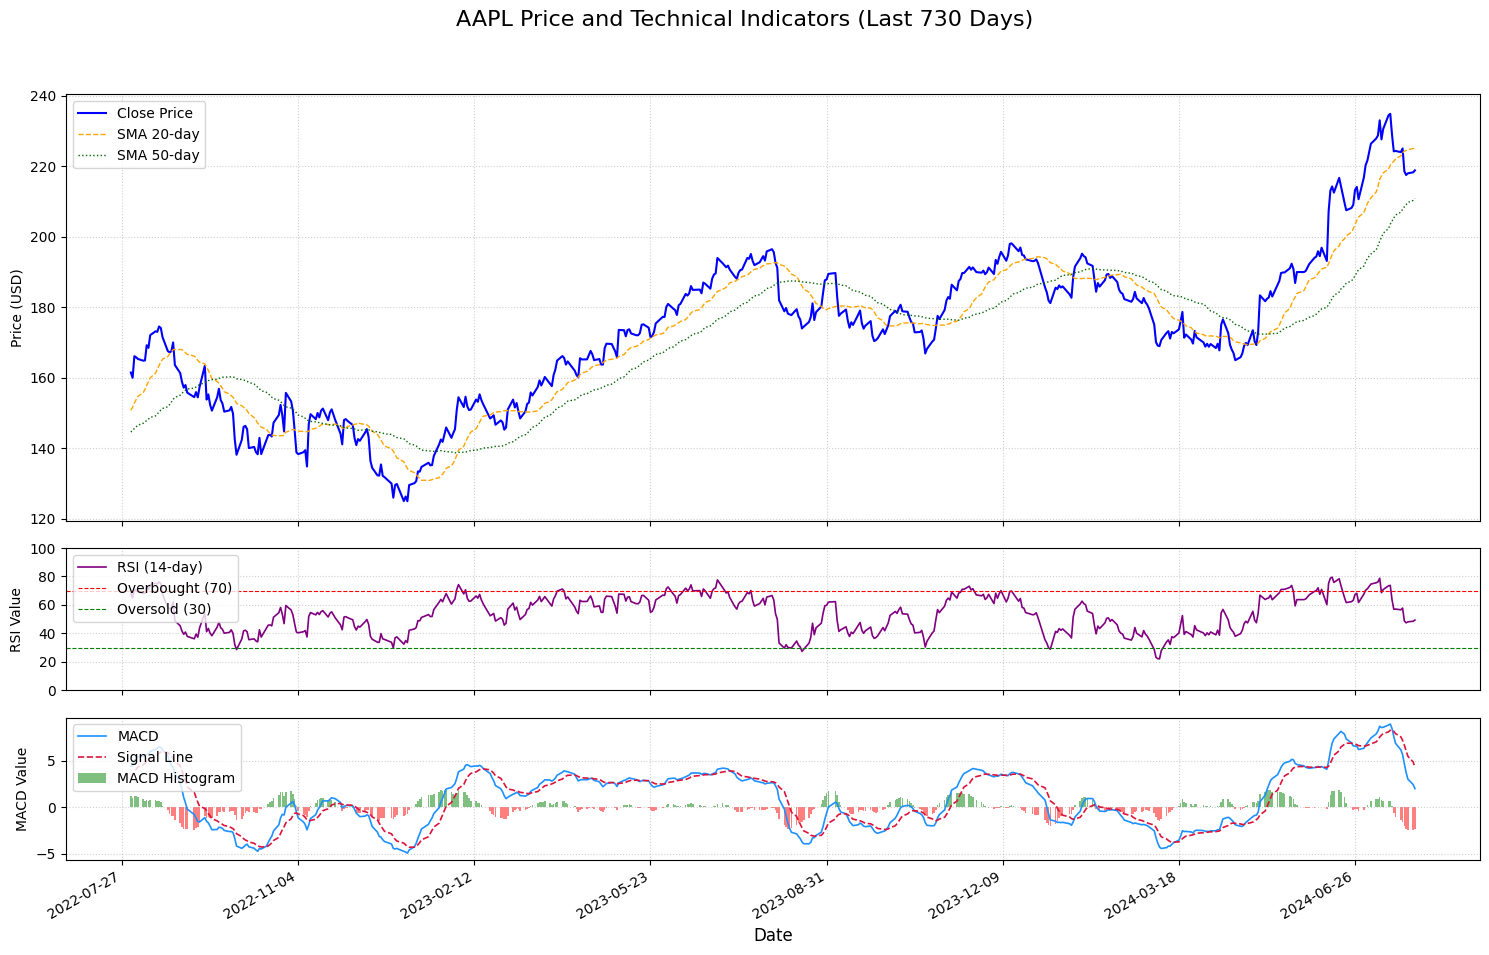

In [24]:
#%%
# --- AAPL - Config ---
ticker_aapl = 'AAPL'
aapl_df = None
aapl_csv_path = ticker_csv_paths.get(ticker_aapl) # Assumes ticker_csv_paths is defined in a previous cell

if aapl_csv_path:
    aapl_df = load_and_clean_stock_data(aapl_csv_path, ticker_aapl)

# --- AAPL - Analysis and Plotting ---
if 'aapl_df' in locals() and aapl_df is not None:
    # Option 1: Plot last 252 trading days (approx 1 year)
    # analyze_and_plot_stock(aapl_df, ticker_aapl, plot_lookback_days=252)
    
    # Option 2: Plot last 730 calendar days (approx 2 years)
    analyze_and_plot_stock(aapl_df, ticker_aapl, plot_lookback_days=730)

    # Option 3: Plot full history (if you still want it sometimes)
    # analyze_and_plot_stock(aapl_df, ticker_aapl, plot_lookback_days=None) # or just omit the argument

    # Option 4: Specific date analysis with a shorter plot lookback
    # analyze_and_plot_stock(aapl_df, ticker_aapl, analysis_date_str='2023-05-01', plot_lookback_days=180) # Last 6 months
else:
    print(f"{ticker_aapl} data not loaded. Run the loading cell first.")